In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("Environment Ready! Scikit-learn version:", sklearn.__version__)


Environment Ready! Scikit-learn version: 1.6.1


In [3]:
# Create a text/markdown cell above this titled: "# 1. Data Loading and Basic EDA"
from sklearn.datasets import load_iris

# Load data
iris_raw = load_iris()
df = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)
df['species'] = iris_raw.target

# Map numerical targets back to their real text names for clear visualization later
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# --- MANDATORY STEPS FOR THE RUBRIC ---
print("--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- DATA STRUCTURAL INFO ---")
print(df.info())

print("\n--- STATISTICAL SUMMARY ---")
print(df.describe())

print("\n--- MISSING VALUES CHECK ---")
print(df.isnull().sum())

--- FIRST 5 ROWS ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

--- DATA STRUCTURAL INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)

/tmp/ipykernel_1250/1139519685.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y='petal width (cm)', ax=axes[0,1], palette='Set2')
/tmp/ipykernel_1250/1139519685.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='species_name', y='petal length (cm)', ax=axes[1,1], palette='Set2', errorbar=None)


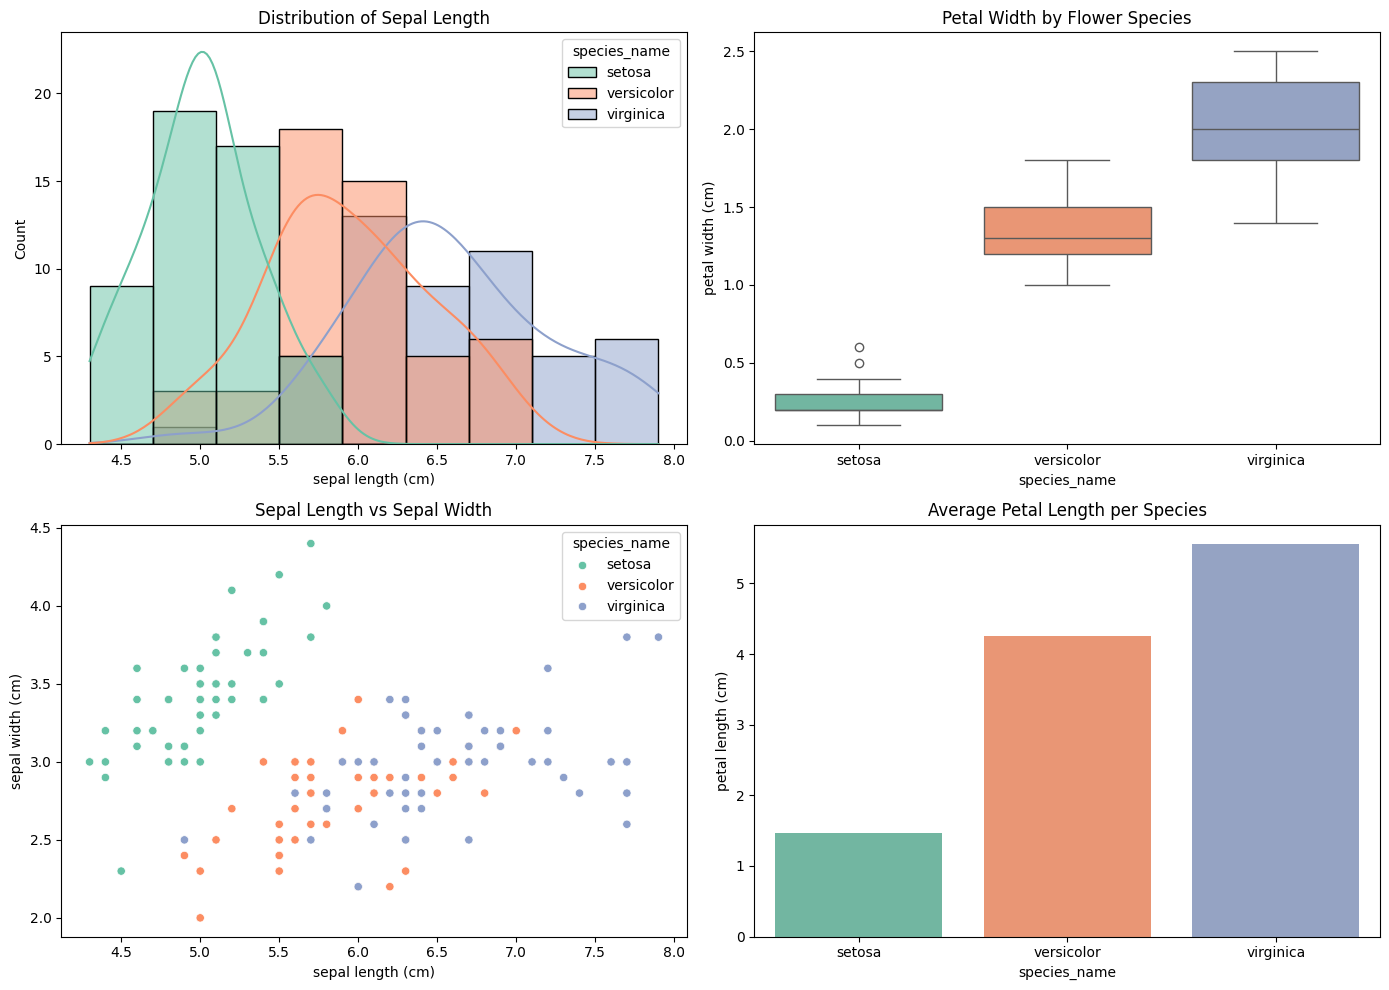

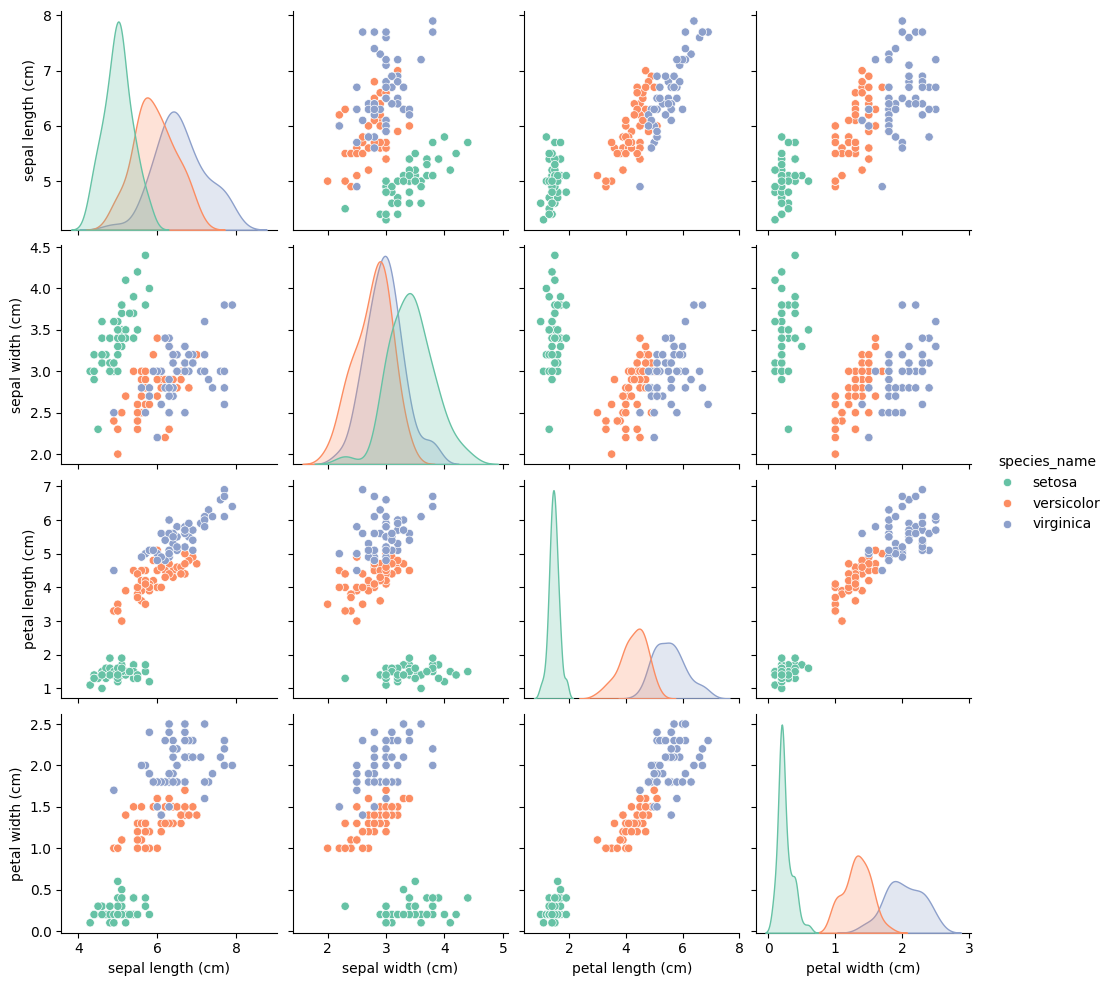

In [4]:
# Create a text/markdown cell above this titled: "# 2. Exploratory Data Analysis Visualizations"
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram (Distribution of Sepal Length)
sns.histplot(data=df, x='sepal length (cm)', hue='species_name', kde=True, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Distribution of Sepal Length')

# Plot 2: Boxplot (Petal Width distribution across Species)
sns.boxplot(data=df, x='species_name', y='petal width (cm)', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Petal Width by Flower Species')

# Plot 3: Scatter Plot (Sepal Length vs Sepal Width)
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='species_name', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Sepal Length vs Sepal Width')

# Plot 4: Bar Chart (Average Petal Length per Species)
sns.barplot(data=df, x='species_name', y='petal length (cm)', ax=axes[1,1], palette='Set2', errorbar=None)
axes[1,1].set_title('Average Petal Length per Species')

plt.tight_layout()
plt.show()

# Extra Bonus: InternSpark mentioned a pairplot alternative. It opens in its own window:
sns.pairplot(df.drop(columns=['species']), hue='species_name', palette='Set2')
plt.show()

In [5]:
# Create a text/markdown cell above this titled: "# 3. Model Training"
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Define Features (X) and Target (y)
X = df.drop(columns=['species', 'species_name'])
y = df['species']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features so they have a mean of 0 and variance of 1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the baseline model
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

print("Baseline Logistic Regression model trained successfully!")

Baseline Logistic Regression model trained successfully!


Overall Model Accuracy: 100.00%

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



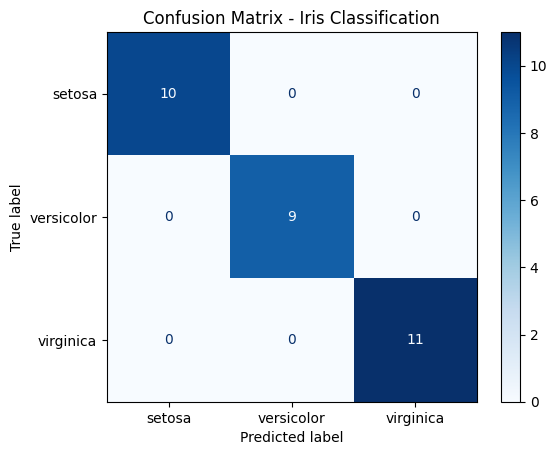

In [6]:
# Create a text/markdown cell above this titled: "# 4. Model Evaluation Metrics"
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
y_pred = model.predict(X_test_scaled)

# Calculate and display metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris_raw.target_names))

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris_raw.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Iris Classification")
plt.show()

In [7]:
# Create a text/markdown cell above this titled: "# 5. Exporting Deployment Artifacts"
# Save the model
joblib.dump(model, 'iris_logistic_regression_model.pkl')

# Crucial: Save the scaler too, so production data can be normalized identical to your training set
joblib.dump(scaler, 'iris_scaler.pkl')

print("Artifacts saved locally to your Colab session memory!")
print("Files generated: 'iris_logistic_regression_model.pkl' and 'iris_scaler.pkl'")

Artifacts saved locally to your Colab session memory!
Files generated: 'iris_logistic_regression_model.pkl' and 'iris_scaler.pkl'
